# Urban Sound Classification and Detection for Edge Devices (Raspberry pi4)
**Project Goal:** To develop a lightweight CNN using Depthwise Separable Convolutions for deployment on a Raspberry Pi 4.
**Dataset:** UrbanSound8K
**Methodology:** 3-Iteration Cross-Validation using pre-defined folds.

#Imports and Setup

In [ ]:
import pandas as pd
import numpy as np
import librosa
import os
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Constants
SR = 16000
N_MELS = 64
DURATION = 3 
INPUT_SHAPE = (64, 94, 1)
DATA_ROOT = "../../UrbanSound8K" 

#Feature Extraction Visualizer

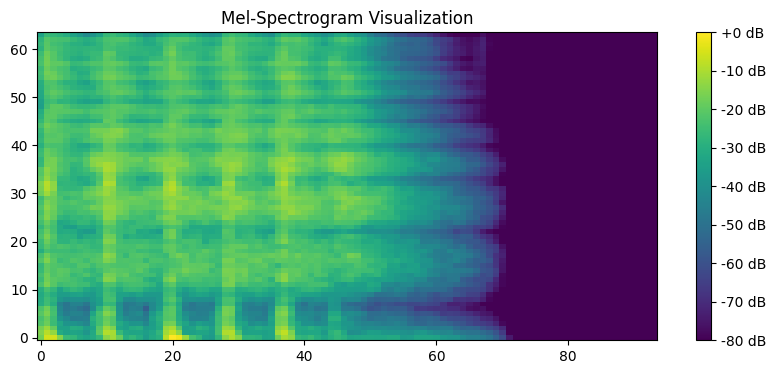

In [ ]:
def extract_features(fold, filename):
    file_path = os.path.join(DATA_ROOT, "audio", f"fold{fold}", filename)
    audio, _ = librosa.load(file_path, sr=SR, duration=DURATION)
    if len(audio) < SR * DURATION:
        audio = np.pad(audio, (0, SR * DURATION - len(audio)))
    mel = librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=N_MELS)
    return librosa.power_to_db(mel, ref=np.max)

# Visualize a sample
sample_mel = extract_features(1, "7061-6-0-0.wav") 
plt.figure(figsize=(10, 4))
plt.imshow(sample_mel, aspect='auto', origin='lower')
plt.title("Mel-Spectrogram Visualization")
plt.colorbar(format='%+2.0f dB')
plt.show()

#Data Loading Logic

In [7]:
df = pd.read_csv(os.path.join(DATA_ROOT, "metadata", "UrbanSound8K.csv"))

def get_dataset(fold_list):
    X, y = [], []
    subset = df[df['fold'].isin(fold_list)]
    for _, row in subset.iterrows():
        feat = extract_features(row['fold'], row['slice_file_name'])
        if feat is not None:
            X.append(feat[..., np.newaxis])
            y.append(row['classID'])
    return np.array(X, dtype='float32'), np.array(y, dtype='int32')

#Proposed Lightweight Model Architecture

In [8]:
def build_proposed_model():
    model = models.Sequential([
        layers.Input(shape=INPUT_SHAPE),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        
        # Depthwise Separable Convolution (The "Edge" Optimization)
        layers.SeparableConv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

build_proposed_model().summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 94, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 94, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 32, 47, 64)     │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 47, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,714 (49.66 KB)

 Trainable params: 12,522 (48.91 KB)

 Non-trainable params: 192 (768.00 B)

#The 3-Iteration Training Loop



--- Running Iteration 1 ---
Epoch 1/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 23s 118ms/step - accuracy: 0.2890 - loss: 1.9482 - val_accuracy: 0.3309 - val_loss: 2.0749
Epoch 2/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 20s 118ms/step - accuracy: 0.4622 - loss: 1.4829 - val_accuracy: 0.2743 - val_loss: 2.0474
Epoch 3/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 20s 118ms/step - accuracy: 0.5359 - loss: 1.2574 - val_accuracy: 0.3388 - val_loss: 2.1327
Epoch 4/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 20s 119ms/step - accuracy: 0.5913 - loss: 1.1295 - val_accuracy: 0.4057 - val_loss: 1.7063
Epoch 5/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 20s 118ms/step - accuracy: 0.6294 - loss: 1.0674 - val_accuracy: 0.3461 - val_loss: 2.7602
Epoch 6/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 21s 124ms/step - accuracy: 0.6399 - loss: 1.0098 - val_accuracy: 0.3680 - val_loss: 2.1663
Epoch 7/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 20s 116ms/step - accuracy: 0.6700 - loss: 0.9411 - val_accuracy: 0.5353 - val_loss: 1.4037
Epoch 8/15
170/170 ━━━━━━━━━━━━━━━━━━━━ 21s 122ms/step

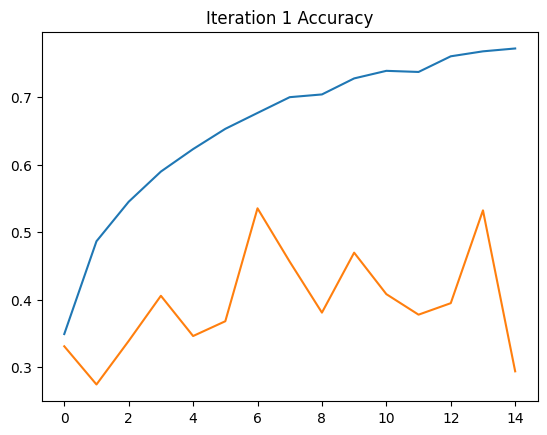

52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
              precision    recall  f1-score   support

           0       0.60      0.01      0.03       200
           1       0.97      0.46      0.62        65
           2       0.27      0.28      0.27       200
           3       0.76      0.42      0.54       200
           4       1.00      0.12      0.21       200
           5       0.55      0.43      0.48       182
           6       0.73      0.76      0.74        63
           7       0.80      0.55      0.65       178
           8       0.19      1.00      0.31       165
           9       0.75      0.18      0.29       200

    accuracy                           0.38      1653
   macro avg       0.66      0.42      0.42      1653
weighted avg       0.64      0.38      0.37      1653


--- Running Iteration 2 ---
Epoch 1/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 22s 115ms/step - accuracy: 0.2619 - loss: 2.0268 - val_accuracy: 0.3001 - val_loss: 2.0599
Epoch 2/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 1

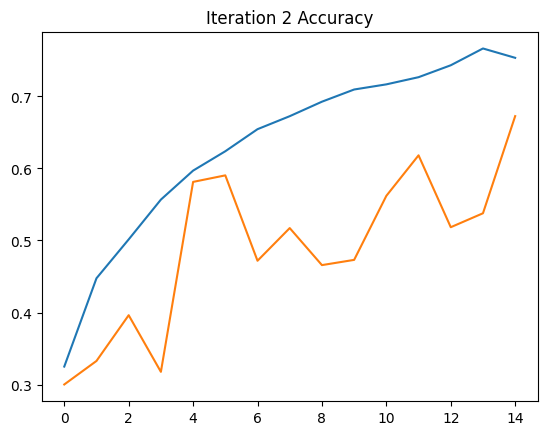

56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
              precision    recall  f1-score   support

           0       0.43      0.29      0.35       200
           1       0.72      0.77      0.75        78
           2       0.67      0.82      0.74       200
           3       0.60      0.93      0.73       200
           4       0.75      0.58      0.66       200
           5       0.28      0.46      0.35       196
           6       0.80      0.76      0.78        70
           7       0.55      0.25      0.35       240
           8       0.67      0.70      0.69       177
           9       0.89      0.67      0.76       200

    accuracy                           0.59      1761
   macro avg       0.64      0.62      0.61      1761
weighted avg       0.62      0.59      0.59      1761


--- Running Iteration 3 ---
Epoch 1/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 22s 120ms/step - accuracy: 0.2817 - loss: 1.9310 - val_accuracy: 0.3390 - val_loss: 2.0130
Epoch 2/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 1

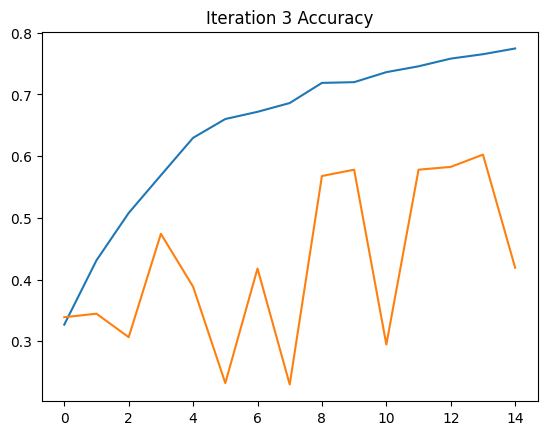

60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step
              precision    recall  f1-score   support

           0       0.35      0.28      0.31       200
           1       0.69      0.47      0.56       102
           2       0.50      0.01      0.03       200
           3       0.61      0.64      0.62       200
           4       0.39      0.67      0.49       200
           5       0.45      0.44      0.45       214
           6       1.00      0.39      0.56        74
           7       0.15      0.07      0.09       240
           8       0.35      0.94      0.50       285
           9       1.00      0.04      0.08       200

    accuracy                           0.41      1915
   macro avg       0.55      0.39      0.37      1915
weighted avg       0.49      0.41      0.35      1915



In [9]:
iterations = [
    {'train': [1,2,3,4,5,6], 'val': [7,8], 'test': [9,10]},
    {'train': [3,4,5,6,7,8], 'val': [9,10], 'test': [1,2]},
    {'train': [5,6,7,8,9,10], 'val': [1,2], 'test': [3,4]}
]

for i, config in enumerate(iterations):
    print(f"\n--- Running Iteration {i+1} ---")
    X_train, y_train = get_dataset(config['train'])
    X_val, y_val = get_dataset(config['val'])
    X_test, y_test = get_dataset(config['test'])
    
    model = build_proposed_model()
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=15, batch_size=32)
    
    # Plotting
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='val')
    plt.title(f"Iteration {i+1} Accuracy")
    plt.show()
    
    # Classification Report
    y_pred = np.argmax(model.predict(X_test), axis=1)
    print(classification_report(y_test, y_pred))

#Final Conversion to TFLite

In [ ]:
import tensorflow as tf  

# Convert the final model to TFLite for Raspberry Pi
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('urban_audio_edge.tflite', 'wb') as f:
    f.write(tflite_model)
print("Edge Model Ready for Raspberry Pi!")

INFO:tensorflow:Assets written to: C:\Users\DELL-PC\AppData\Local\Temp\tmpkm82tn7e\assets


INFO:tensorflow:Assets written to: C:\Users\DELL-PC\AppData\Local\Temp\tmpkm82tn7e\assets


Saved artifact at 'C:\Users\DELL-PC\AppData\Local\Temp\tmpkm82tn7e'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 94, 1), dtype=tf.float32, name='keras_tensor_33')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  2856896899728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2856597759424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2858243141296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2858243139008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2858243140240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2858243139536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2858261339824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2857371281712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2858261337888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2856896863216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2